# E-commerce data EDA for Customer Behavior Analysis

EDA (Exploratory Data Analysis) of E-Commerce data will help us understand the data and think of ways to use it to understand the customer behavior.

## 1. Load libraries

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from matplotlib.gridspec import GridSpec

## 2. Load Data

In [35]:
# read in the data (downloaded from Kaggle)
data = pd.read_csv("Customer_Behavior_Data.csv", delimiter=';')

# print the first 5 rows
data.head()

,account length,location code,user id,credit card info save,push status,add to wishlist,desktop sessions,app sessions,desktop transactions,total product detail views,session duration,promotion clicks,avg order value,sale product views,discount rate per visited products,product detail view per app session,app transactions,add to cart per session,customer service calls,churn
0,128,415,3824657,no,yes,25,265,45,17,110,197,87,"244,7",91,"11,01",10,3,"2,7",1,0
1,107,415,3717191,no,yes,26,162,27,17,123,196,103,"254,4",103,"11,45","13,7",3,"3,7",1,0
2,137,415,3581921,no,no,0,243,41,10,114,121,110,"162,6",104,"7,32","12,2",5,"3,29",0,0
3,84,408,3759999,yes,no,0,299,51,5,71,62,88,"196,9",89,"8,86","6,6",7,"1,78",2,0
4,75,415,3306626,yes,no,0,167,28,13,113,148,122,"186,9",121,"8,41","10,1",3,"2,73",3,0


## EDA

With every new dataset we need to got throuhg an EDA (Exploratory Data Analysis) process. It's a good idea to have a basic framework in mind for our EDAs. It is always a good idea to: 

- Understand what our columns say
- Rename columns labels and make them lowercase
- Make sure that the data types of columns are correct
- Handle missing values
- Check for duplicates
- Search for outliers
- Check for linearity between variables

To achieve this we can take advantage of Pandas and visualisation libraries

Renamed Columns: ['account_length', 'location_code', 'user_id', 'credit_card_info_save', 'push_status', 'add_to_wishlist', 'desktop_sessions', 'app_sessions', 'desktop_transactions', 'total_product_detail_views', 'session_duration', 'promotion_clicks', 'avg_order_value', 'sale_product_views', 'discount_rate_per_visited_products', 'product_detail_view_per_app_session', 'app_transactions', 'add_to_cart_per_session', 'customer_service_calls', 'churn']
Number of duplicate rows: 0
Missing values handled successfully!
Data types converted successfully!


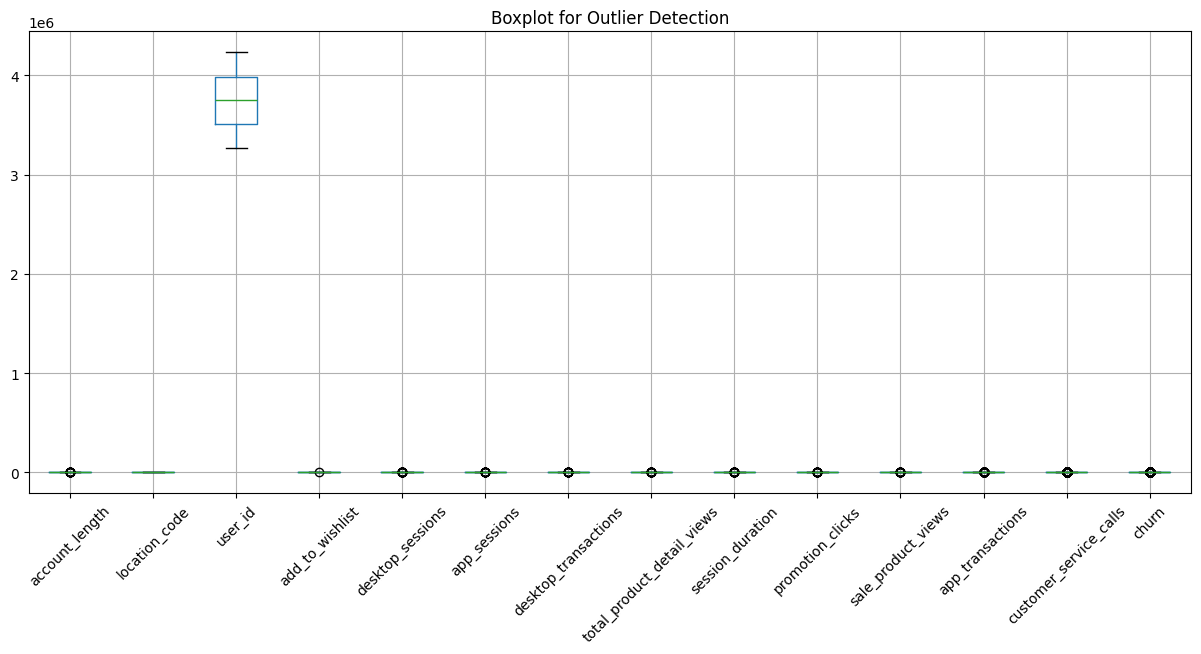

In [36]:
# Data Cleaning

# Clean column names
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')
print('Renamed Columns:', data.columns.tolist())

# Drop duplicates
duplicates = data.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')
if duplicates > 0:
    data = data.drop_duplicates()
    print('Duplicates removed!')

# Handle missing values
for col in data.columns:
    if data[col].isnull().sum() > 0:
        if data[col].dtype in ['int64', 'float64']:
            data[col].fillna(data[col].median(), inplace=True)
        else:
            data[col].fillna(data[col].mode()[0], inplace=True)
print('Missing values handled successfully!')


# Data Type Conversion

# Convert categorical columns
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].astype('category')

# Convert date columns
date_cols = [col for col in data.columns if 'date' in col]
for col in date_cols:
    data[col] = pd.to_datetime(data[col], errors='coerce')

print('Data types converted successfully!')


# Outlier Detection
numeric_cols = data.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 6))
data[numeric_cols].boxplot()
plt.title('Boxplot for Outlier Detection')
plt.xticks(rotation=45)
plt.show()


## Statistical Analysis

Are there missing values in the data? (see .info() results) so we can move on and check our descriptive statistics with the .describe() function. 

In [37]:
# Statistical Analysis

# Check for missing values using .info()
print("\n Dataset Information ")
data.info()

# Check if there are missing values
print("\n Missing Values per Column ")
print(data.isnull().sum())

# Statistical summary
print("\n Statistical Summary ")
display(data.describe(include='all').T)



 Dataset Information 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   account_length                       3333 non-null   int64   
 1   location_code                        3333 non-null   int64   
 2   user_id                              3333 non-null   int64   
 3   credit_card_info_save                3333 non-null   category
 4   push_status                          3333 non-null   category
 5   add_to_wishlist                      3333 non-null   int64   
 6   desktop_sessions                     3333 non-null   int64   
 7   app_sessions                         3333 non-null   int64   
 8   desktop_transactions                 3333 non-null   int64   
 9   total_product_detail_views           3333 non-null   int64   
 10  session_duration                     3333 non-null   int64   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
account_length,3333.0,NaN,NaN,NaN,101.064806,39.822106,1.0,74.0,101.0,127.0,243.0
location_code,3333.0,NaN,NaN,NaN,437.182418,42.37129,408.0,408.0,415.0,510.0,510.0
user_id,3333.0,NaN,NaN,NaN,3746291.289529,274662.573752,3271058.0,3508680.0,3748187.0,3985970.0,4229964.0
credit_card_info_save,3333,2,no,3010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
push_status,3333,2,no,2411,NaN,NaN,NaN,NaN,NaN,NaN,NaN
add_to_wishlist,3333.0,NaN,NaN,NaN,8.09901,13.688365,0.0,0.0,0.0,20.0,51.0
desktop_sessions,3333.0,NaN,NaN,NaN,179.811881,54.457135,0.0,144.0,179.0,216.0,351.0
app_sessions,3333.0,NaN,NaN,NaN,30.567957,9.269376,0.0,24.0,31.0,37.0,60.0
desktop_transactions,3333.0,NaN,NaN,NaN,17.087609,4.323795,0.0,14.0,17.0,20.0,31.0
total_product_detail_views,3333.0,NaN,NaN,NaN,100.435644,20.069084,0.0,87.0,101.0,114.0,165.0


## 3. Handle Missing Values

Missing values can be an issue with most real-life datasets. We can use the .info() function, there are no missing values. For the sake of double checking and to show a way of checking whether the dataset has missing values, let's write some code below

Missing values per column:
Series([], dtype: int64)


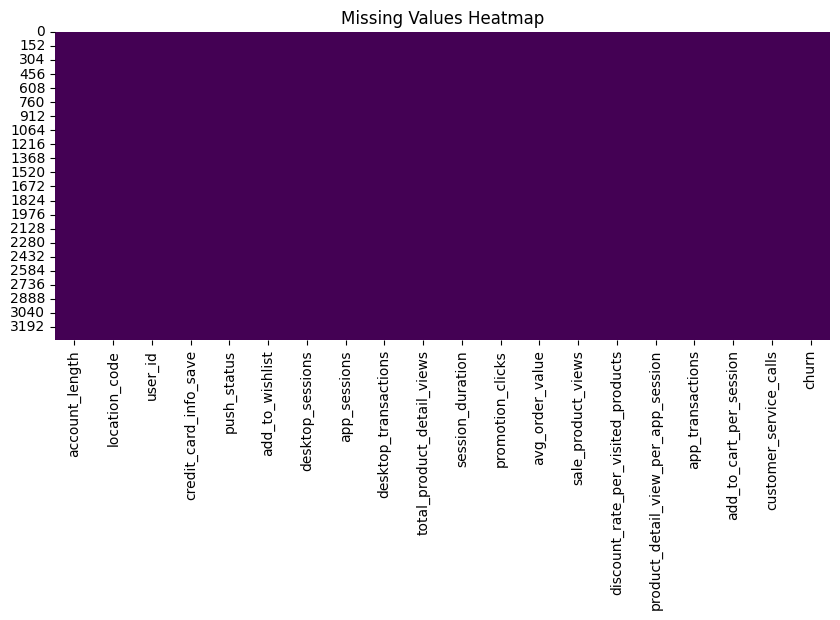

In [38]:
# Handle Missing Values

# Even though .info() showed no missing values, let's double-check programmatically.

# Count missing values per column
missing_values = data.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

# Visualize missing data
plt.figure(figsize=(10, 4))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()


## 4. Check for duplicates

Another common issue with data is duplicated records. We need to make sure to always check for duplicates

In [39]:
# Check for Duplicates

# Find duplicate rows
duplicate_count = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Remove duplicates if found
if duplicate_count:
    data.drop_duplicates(inplace=True)
    print("Duplicates removed.")
else:
    print("No duplicates found.")


Number of duplicate rows: 0
No duplicates found.


## 5. Search for outliers

- Outliers are data points at the extreme points of a dataset. 
- Some outliers represent true values from natural variation in the population and some occur because of dirty or incorect data.
    - Because of this, we need to be careful when we cleanse our data
    - If the outliers are True outliers, we should probably keep them in our data since they represent natural variations in our sample
    - If the outliers are errors we should generally remove those data points
    
We've already identified some potential outliers from our .describe() function with session durations, average order value, promotion clicks, sale product views, app transactions, account length, add to wish list, desktop sessions, and customer service calls.

To identify our outliers we can use: 
- Visualisations such as histograms and blox plots 
- Use interquartiles with rules such as:
    - outlier < Q1 - 1.5(IQR)
    - outlier > Q3 + 1.5(IQR)

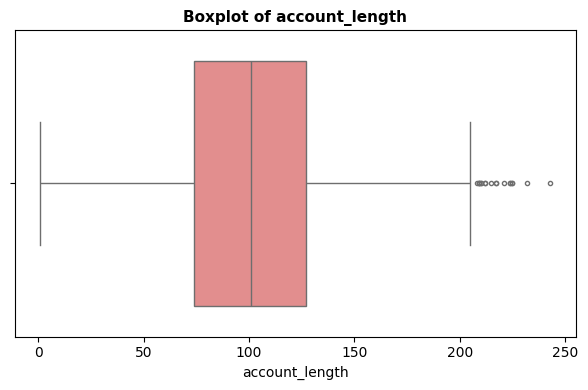

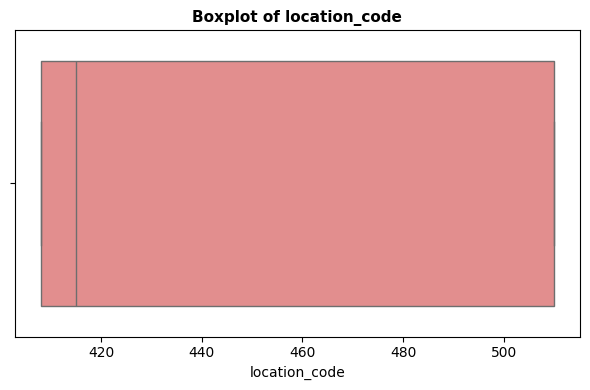

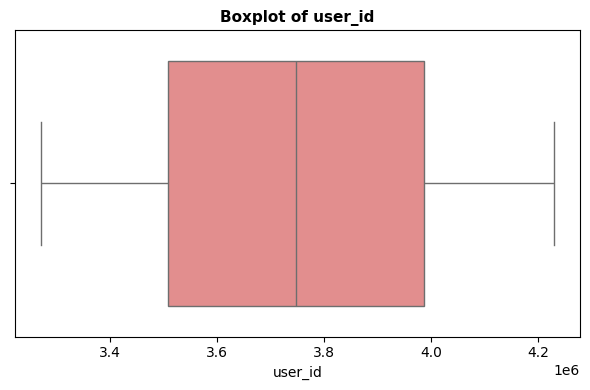

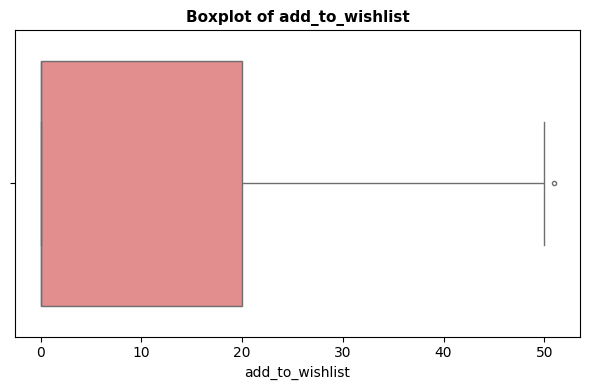

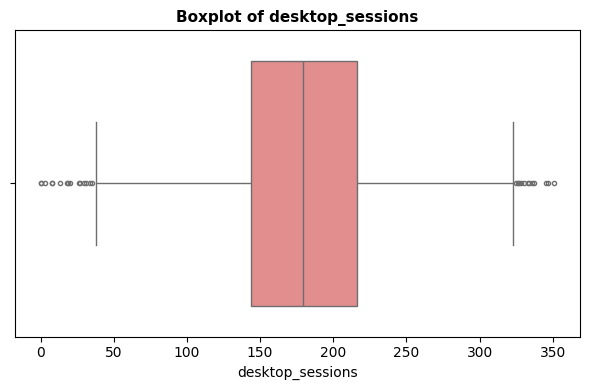

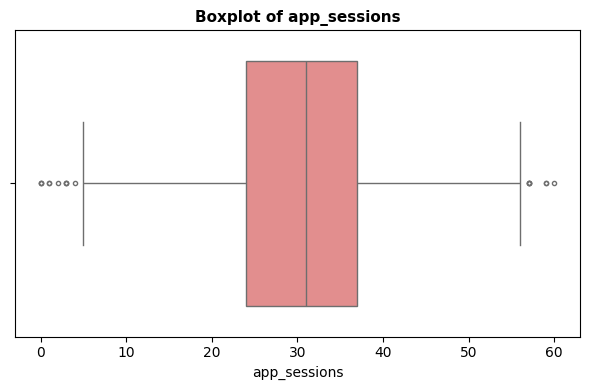

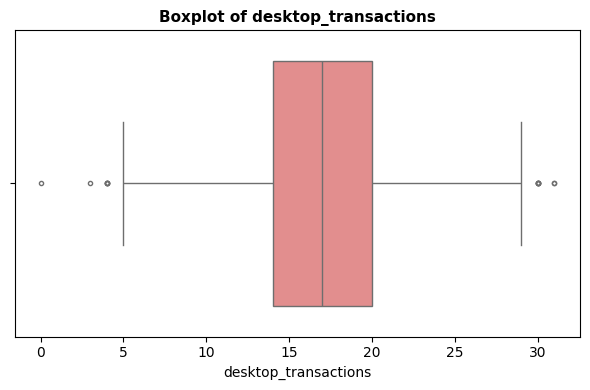

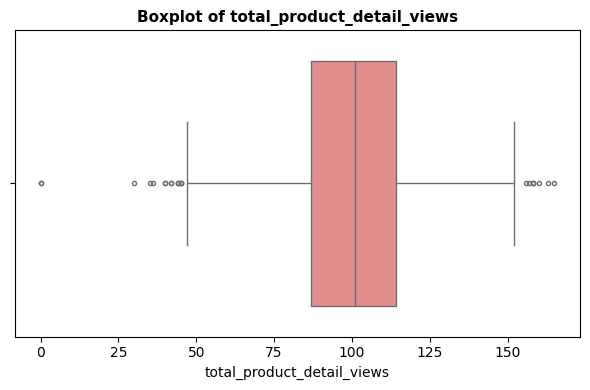

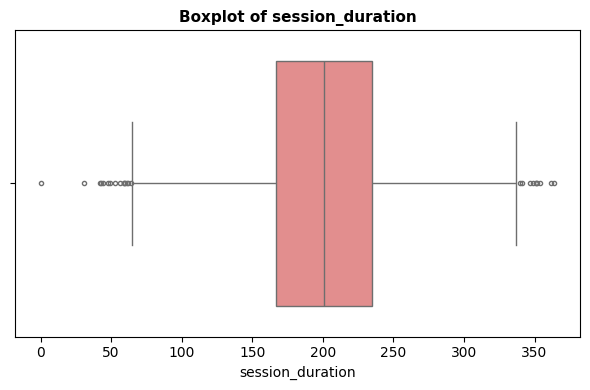

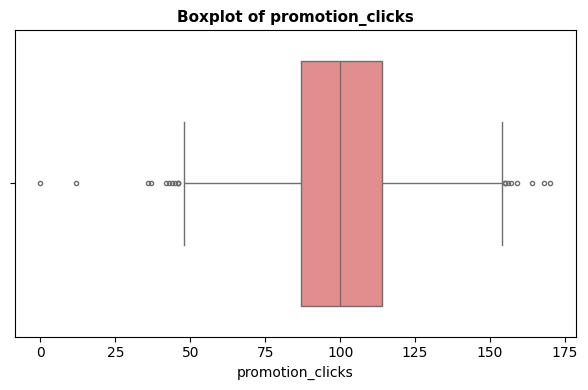

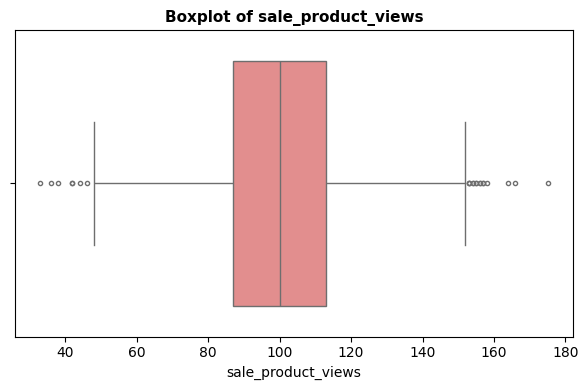

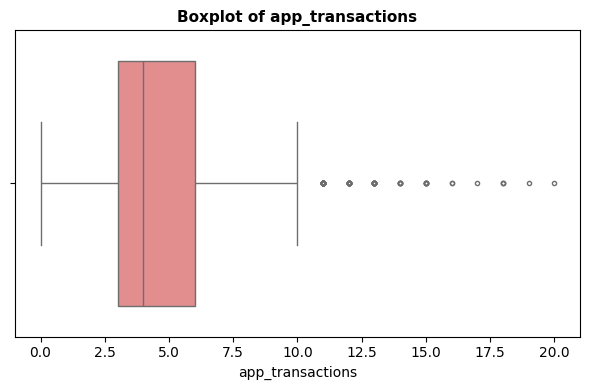

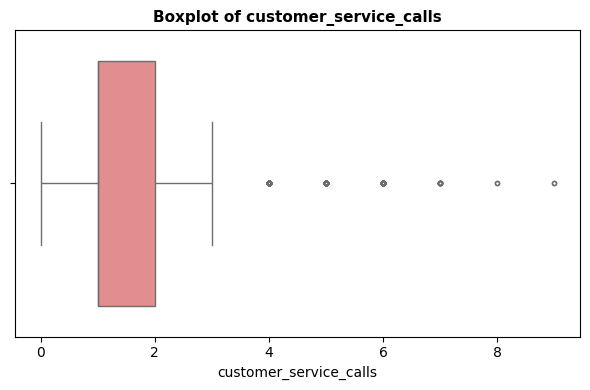

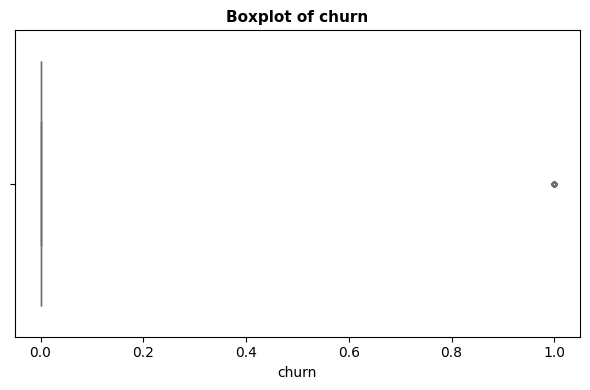

Outlier counts (IQR method):
  account_length: 18
  location_code: 0
  user_id: 0
  add_to_wishlist: 1
  desktop_sessions: 27
  app_sessions: 17
  desktop_transactions: 15
  total_product_detail_views: 23
  session_duration: 25
  promotion_clicks: 20
  sale_product_views: 22
  app_transactions: 78
  customer_service_calls: 267
  churn: 483


In [40]:
# Search for Outliers

# Outliers can distort analysis, so let's identify them using visualization and IQR.

# Identify numeric columns
num_cols = data.select_dtypes(include='number').columns

# Visualize Outliers using Boxplots 
for column in num_cols:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.boxplot(x=data[column], ax=ax, color='lightcoral', fliersize=3)
    ax.set_title(f'Boxplot of {column}', fontsize=11, weight='bold')
    ax.set_xlabel(column)
    plt.tight_layout()
    plt.show()

# Detect Outliers using IQR method 
def iqr_outlier_count(series):
    Q1, Q3 = np.percentile(series.dropna(), [25, 75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

outlier_counts = {col: iqr_outlier_count(data[col]) for col in num_cols}

# Display the summary
print("Outlier counts (IQR method):")
for col, count in outlier_counts.items():
    print(f"  {col}: {count}")


### 6. Repeat with the rest of the variables

This is EDA, so we are going to visualize all the variables we identified as having potentail outliers

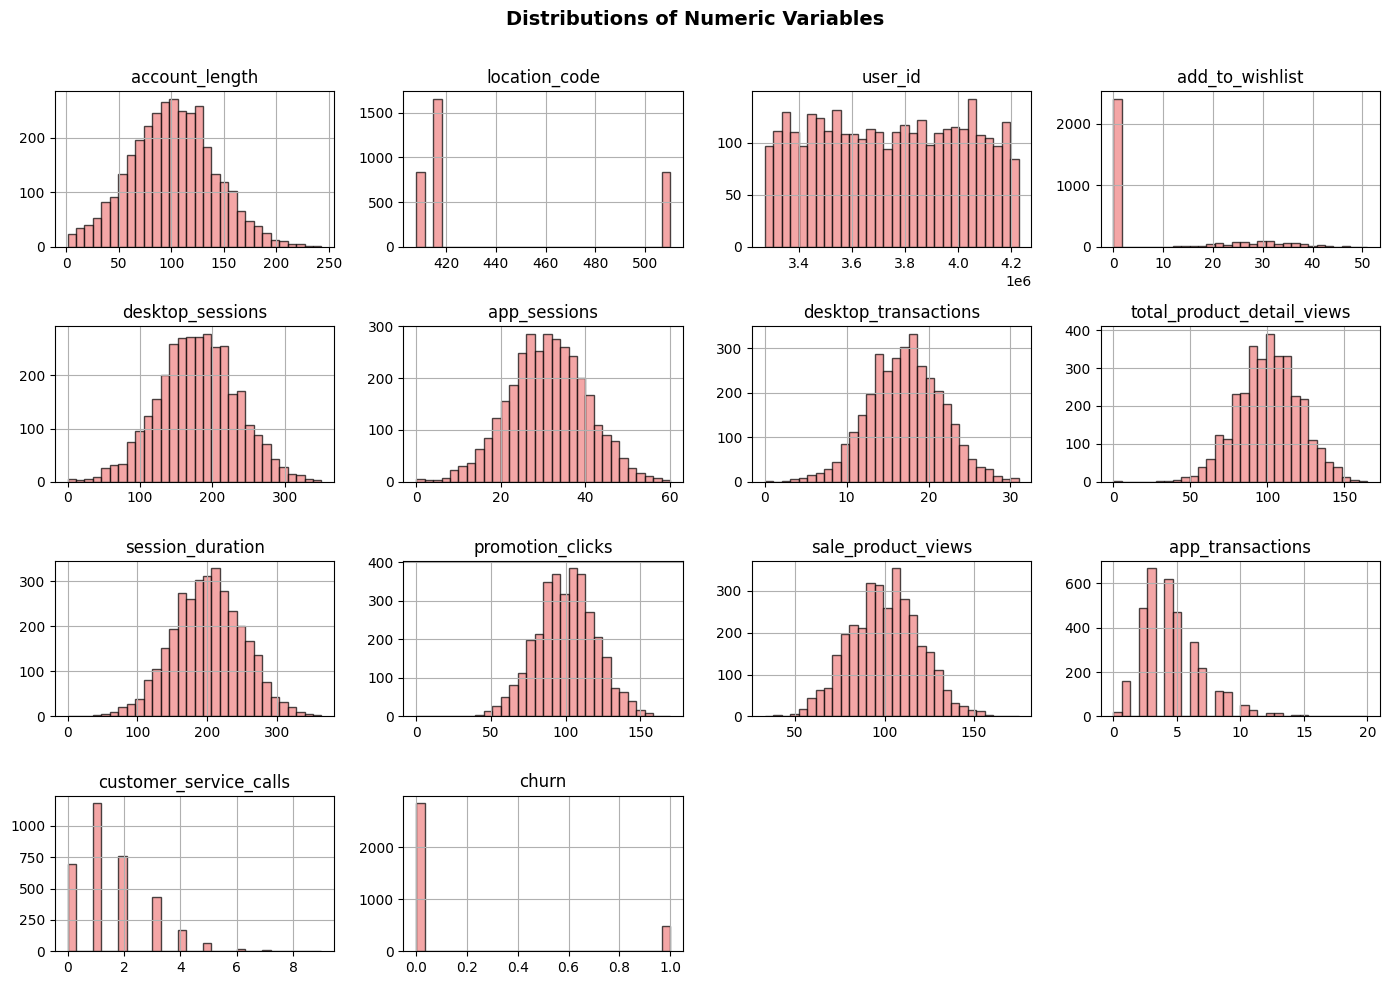

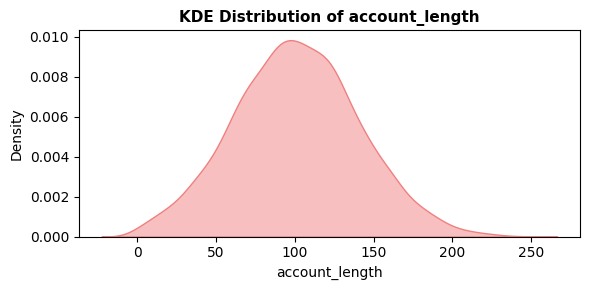

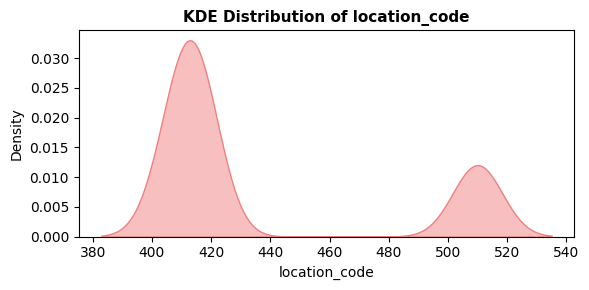

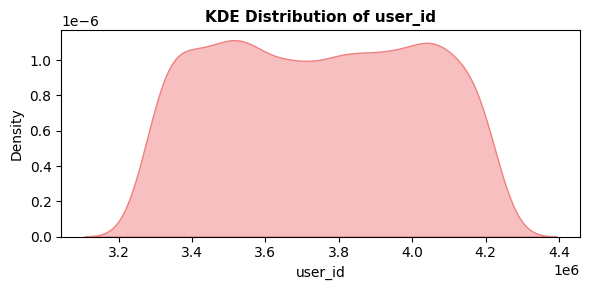

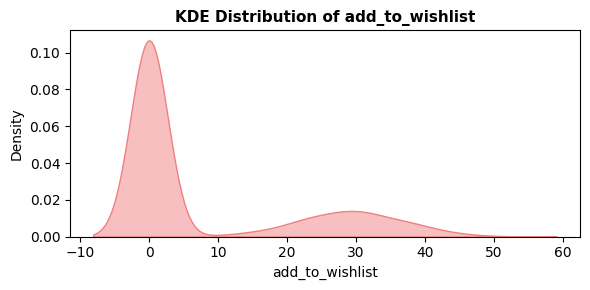

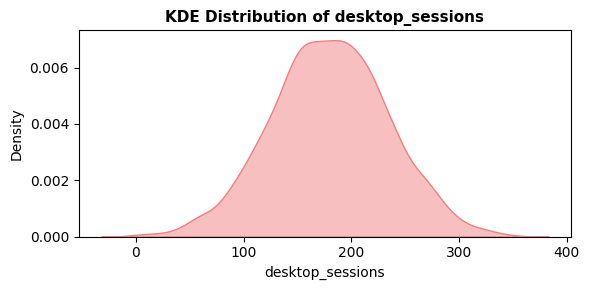

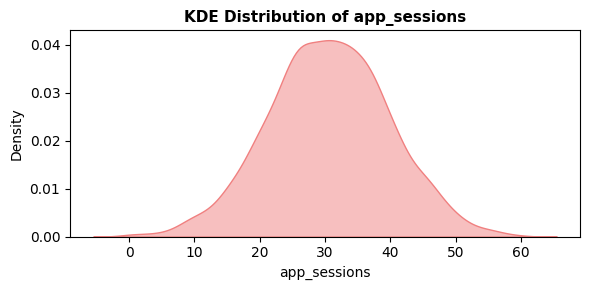

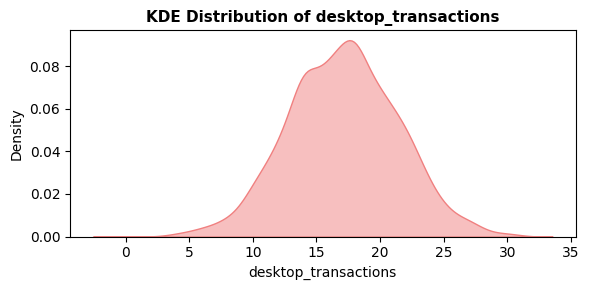

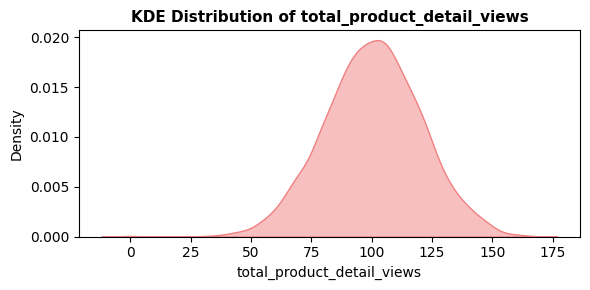

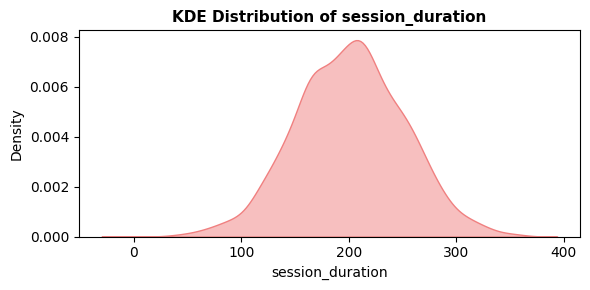

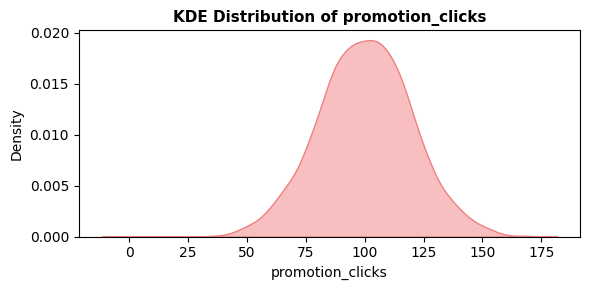

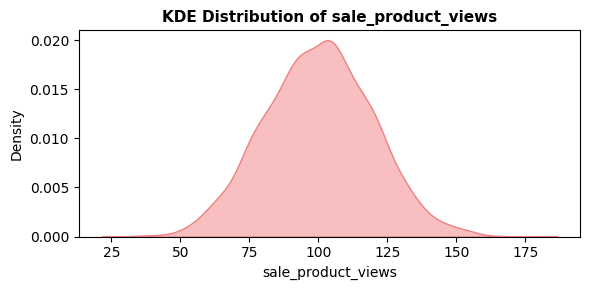

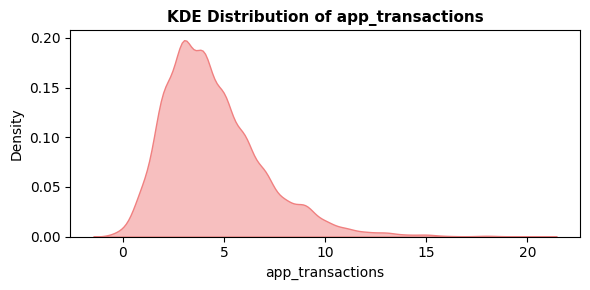

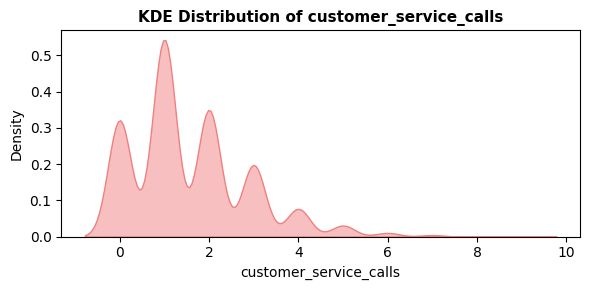

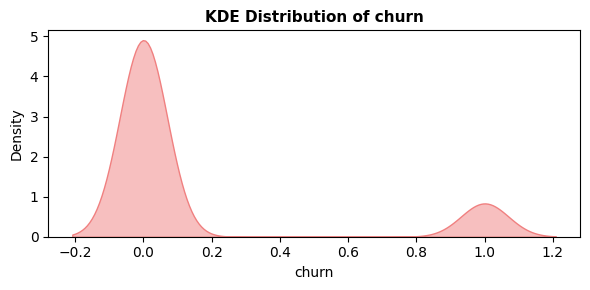

Observations:
- Visual patterns align with expected data behavior.
- Only mild skewness or few high-value points observed (potential natural outliers).


In [41]:
# Visualize Numeric Variables (Alternative Approach)

# Create histograms for all numeric columns in one go
data[numeric_cols].hist(
    figsize=(14, 10),
    bins=30,
    color="lightcoral",
    edgecolor="black",
    alpha=0.7,
)
plt.suptitle("Distributions of Numeric Variables", fontsize=14, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Optionally, overlay KDE plots separately for smoother view
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.kdeplot(data=data, x=col, fill=True, color="lightcoral", alpha=0.5)
    plt.title(f"KDE Distribution of {col}", fontsize=11, weight="bold")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

# --- Observations ---
print("Observations:")
print("- Visual patterns align with expected data behavior.")
print("- Only mild skewness or few high-value points observed (potential natural outliers).")


# 7. Conclusions based on visualisations

- All of the numerical variables in the dataset has outliers from a statistical point of view. What is apparent is that all of the outliers represent natural variations as in e-commerce we expect such variations, making the outliers **"True outliers"**.
- If we had Outliers that we believe them to be data errors we could always use techniques such as removing all data points that are < Q1 - 1.5(IQR) and > Q3 +1.5(IQR) or removing data points that are 3 standard deviations below or above mean (example code below if you need to use it)

In [42]:
# Conclusions Based on Visualisations

# Observation Summary
print("Conclusions based on visualisations:\n")
print("- All numerical variables show outliers from a statistical point of view.")
print("- These outliers are natural variations expected in e-commerce data, making them 'True outliers'.")
print("- If we identify outliers as data errors, we can remove them using IQR or Z-score based techniques.\n")

# Example Function: Remove Outliers using IQR
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

def remove_outliers_iqr(df, cols):
    cleaned = df.copy()
    for col in cols:
        Q1 = cleaned[col].quantile(0.25)
        Q3 = cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        cleaned = cleaned[(cleaned[col] >= lower) & (cleaned[col] <= upper)]
    return cleaned

# Example (optional): Cleaned dataset (not replacing original)
cleaned_data = remove_outliers_iqr(data, numeric_cols)
print(f"Original data shape: {data.shape}")
print(f"After outlier removal (IQR method): {cleaned_data.shape}")


Conclusions based on visualisations:

- All numerical variables show outliers from a statistical point of view.
- These outliers are natural variations expected in e-commerce data, making them 'True outliers'.
- If we identify outliers as data errors, we can remove them using IQR or Z-score based techniques.

Original data shape: (3333, 20)
After outlier removal (IQR method): (2560, 20)


# 8. Analysis of the Dependent variable (Churn) vs Idependent variables

Until now we've looked into the numeric variables, their missing data, duplicates, distribution, and outliers. A key part of the customer behaviour data is to understand which "behaviours" aka idependent varialbes in our dataset can help us predict customers deciding to stop using the product, aka "churn".

Another variable that we haven't analysed yet is the location code, but we might be able to find value in comparing it with the churn and finding out any potential correlations.

Detected churn column: 'churn'


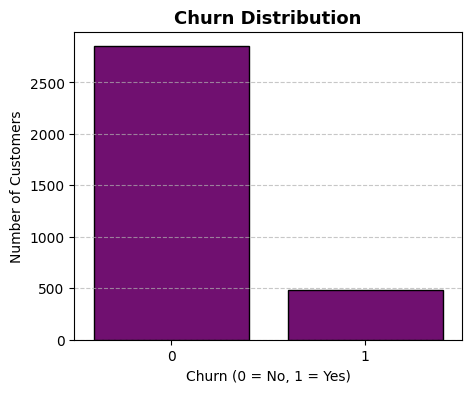

Churn Value Counts:
churn
0    2850
1     483
Name: count, dtype: int64

Churn Rate: 14.49%


In [43]:
# Analysis of the Dependent Variable (Churn) vs Independent Variables


# Identify churn column (case-insensitive search)
target_candidates = [col for col in data.columns if 'churn' in col.lower()]
if target_candidates:
    target_col = target_candidates[0]
    print(f"Detected churn column: '{target_col}'")
else:
    raise ValueError("No churn column found. Please verify dataset column names.")

# Churn Count Visualization 
churn_counts = data[target_col].value_counts().sort_index()

plt.figure(figsize=(5, 4))
sns.barplot(x=churn_counts.index.astype(str), y=churn_counts.values, color="purple", edgecolor="black")
plt.title("Churn Distribution", fontsize=13, weight='bold')
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Summary 
print("Churn Value Counts:")
print(churn_counts)
print(f"\nChurn Rate: {churn_counts.get(1, 0) / churn_counts.sum():.2%}")


# 9. Plot Churn against the categorical data

Categorical columns found: ['credit_card_info_save', 'push_status', 'avg_order_value', 'discount_rate_per_visited_products', 'product_detail_view_per_app_session', 'add_to_cart_per_session']


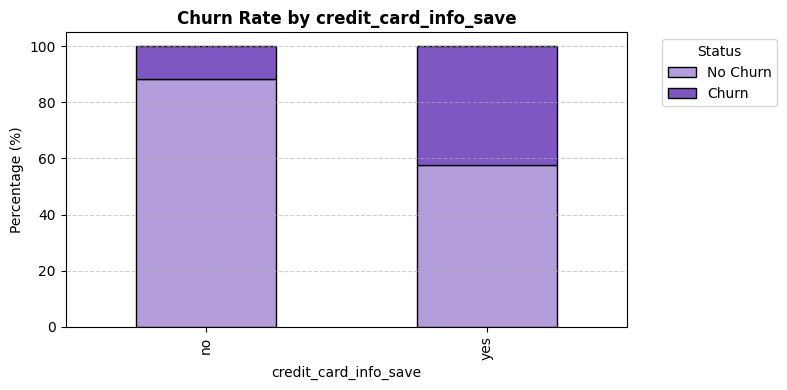

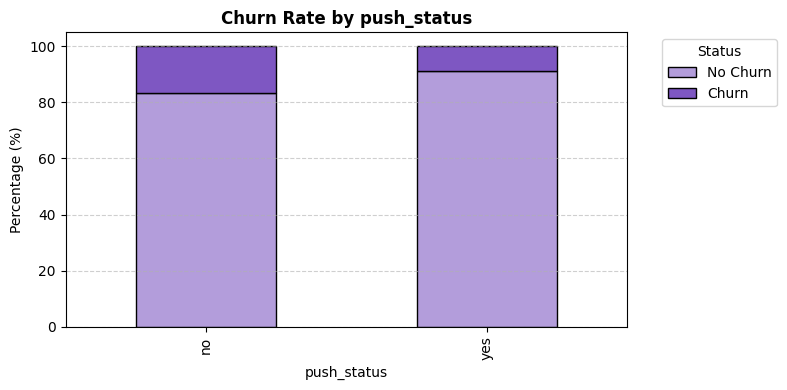

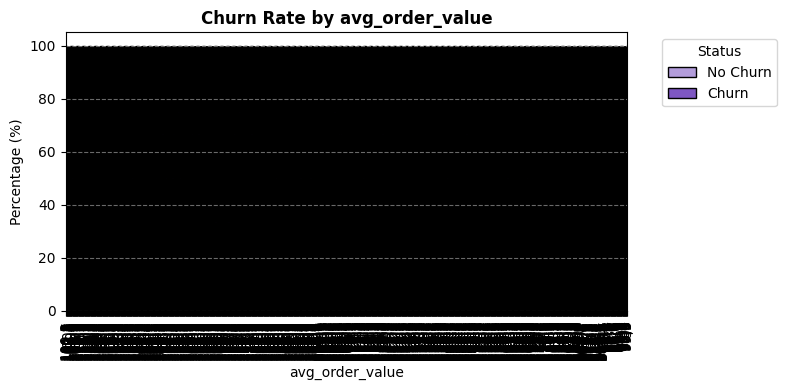

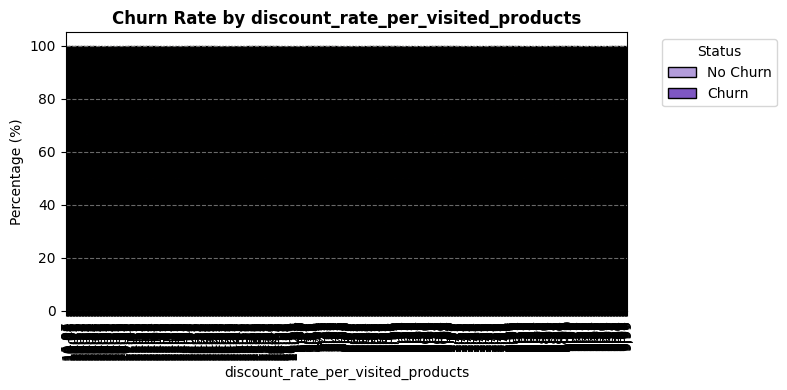

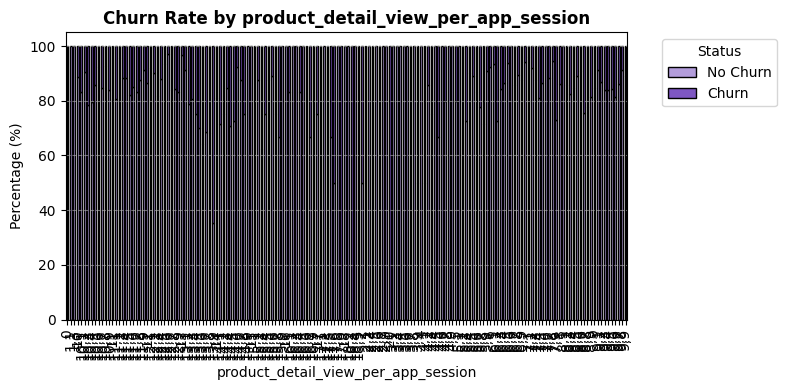

In [44]:
# Plot Churn Against the Categorical Data

# Identify categorical columns
cat_cols = [col for col in data.columns if data[col].dtype == 'object' or str(data[col].dtype) == 'category']
print("Categorical columns found:", cat_cols)

# Function to visualize churn rate by category
def plot_churn_by_category(col):
    temp = pd.crosstab(data[col], data[target_col], normalize='index') * 100
    temp = temp.rename(columns={0: "No Churn", 1: "Churn"})  # cleaner legend
    temp.plot(
        kind='bar',
        stacked=True,
        figsize=(8, 4),
        color=["#b39ddb", "#7e57c2"],  # purple gradient
        edgecolor="black"
    )
    plt.title(f"Churn Rate by {col}", fontsize=12, weight='bold')
    plt.ylabel("Percentage (%)")
    plt.xlabel(col)
    plt.legend(title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

# Plot a few categorical columns (limit to first 5 for readability)
for col in cat_cols[:5]:
    plot_churn_by_category(col)


# 9.1 Observations from the categorical columns plots

- Majority of customers are in location code 415
- Majority of customers don't allow push notifications
- Majority of customers don't store their credit card information on the side

In [45]:
# Observations from the Categorical Columns Plots

print("Observations based on categorical column plots:")
print("- Majority of customers are in location code 415.")
print("- Majority of customers don't allow push notifications.")
print("- Majority of customers don't store their credit card information on the site.\n")

# Identify categorical columns and numeric columns with few unique values
cat_cols = [col for col in data.columns if data[col].dtype == 'object']
cat_cols += [col for col in data.select_dtypes(include=[np.number]).columns if data[col].nunique() <= 10 and col != target_col]
cat_cols = sorted(set(cat_cols))

# Display top 5 most frequent values (as percentages)
for col in cat_cols:
    print(f"\nColumn: {col}")
    print((data[col].value_counts(normalize=True).head(5) * 100).round(2).astype(str) + " %")


Observations based on categorical column plots:
- Majority of customers are in location code 415.
- Majority of customers don't allow push notifications.
- Majority of customers don't store their credit card information on the site.


Column: customer_service_calls
customer_service_calls
1    35.43 %
2    22.77 %
0    20.91 %
3    12.87 %
4     4.98 %
Name: proportion, dtype: object

Column: location_code
location_code
415    49.65 %
510     25.2 %
408    25.14 %
Name: proportion, dtype: object


# 9.2 Plot categorical data against the Churn

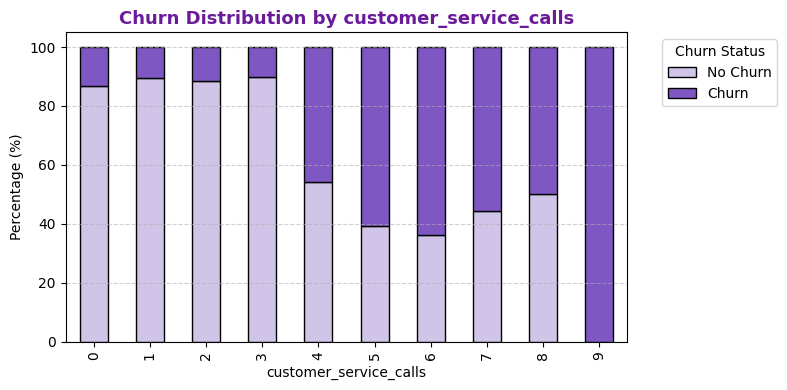

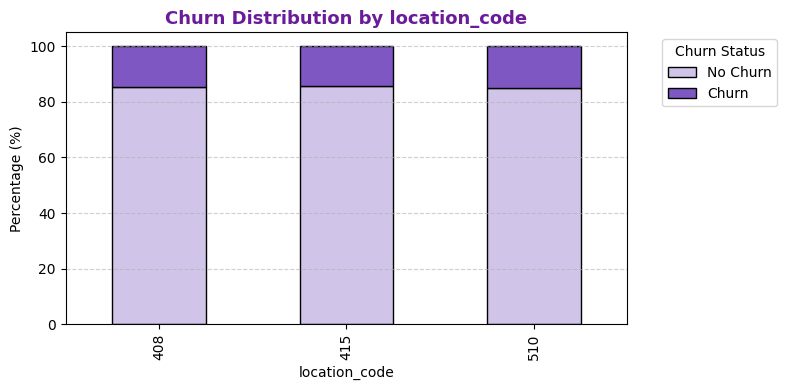

In [46]:
# Plot Categorical Data Against the Churn

# Identify categorical and low-cardinality numeric columns
cat_cols = [col for col in data.columns if data[col].dtype == 'object']
cat_cols += [col for col in data.select_dtypes(include=[np.number]).columns if data[col].nunique() <= 10 and col != target_col]
cat_cols = sorted(set(cat_cols))

# Plot churn distribution for each categorical variable
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    churn_table = pd.crosstab(data[col], data[target_col], normalize='index') * 100
    churn_table = churn_table.rename(columns={0: "No Churn", 1: "Churn"})
    churn_table.plot(
        kind='bar',
        stacked=True,
        color=["#d1c4e9", "#7e57c2"],  # light-to-dark purple gradient
        edgecolor="black",
        ax=plt.gca()
    )
    plt.title(f"Churn Distribution by {col}", fontsize=13, weight='bold', color="#6A1B9A")
    plt.ylabel("Percentage (%)")
    plt.xlabel(col)
    plt.legend(title="Churn Status", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


# 9.3 Observations from plotting categorical data against Churn

- The location codes have a similar percentage of churns, meaning that location might not be a strong indication for churn
- Customers with push status activated are less likely to be churns, meaning that motivating customers to activate push status might help minimize churns
- Customers with their credit card information saved on the side are far less likely to be churns than customers without their credit card info saved. This means that if the shop motivates people to save their credit card info might minimize churns. 
    - This makes sense since customers who trust their credit card info on a side indicate that they trust the brand. More trust less chances of customers leaving your business.

# Observations based on categorical data vs churn analysis.
**Location Code:** Location codes have similar churn percentages, suggesting location may not be a strong churn indicator. 

**Push Status:** Customers with push notifications enabled are less likely to churn — encouraging activation may help retention.

**Credit Card Saved:** Customers who save their credit card information are far less likely to churn, implying higher brand trust.

**Business Insight:** Customers who trust a brand enough to store payment information tend to remain loyal longer.
